In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
shutil.rmtree("preprocessed_data",ignore_errors=True)
shutil.rmtree("data",ignore_errors=True)



In [ ]:
import os
# loading the dataset
path = "drive/MyDrive/piyushsharma5654/ohrc-images-chandaryaan-2"
if not os.path.exists(path):

  import kagglehub

  # Download latest version
  path = kagglehub.dataset_download("piyushsharma5654/ohrc-images-chandaryaan-2")

  print("Path to dataset files:", path)

In [ ]:
path2 = "drive/MyDrive/romainpessia/artificial-lunar-rocky-landscape-dataset"
if not os.path.exists(path2):
  import kagglehub

  # Download latest version
  path2 = kagglehub.dataset_download("romainpessia/artificial-lunar-rocky-landscape-dataset")

  print("Path to dataset files:", path2)

In [ ]:
for f in os.listdir("drive/MyDrive/piyushsharma5654/ohrc-images-chandaryaan-2"):
  if f.split(".")[-1]!="png":
    os.remove(os.path.join("drive/MyDrive/piyushsharma5654/ohrc-images-chandaryaan-2",f))

In [ ]:
os.listdir(path2)

['cam_anomaly_IDs.txt',
 'images',
 'mismatch_IDs.txt',
 'shadow_IDs.txt',
 'top200_largerocks_IDs.txt',
 'ground_facing_IDs.txt',
 'real_moon_images',
 'bounding_boxes.csv']

In [ ]:
import os

p1=os.path.join(path2,"images/render")
p2=path

In [ ]:
os.listdir(p2)

['ch2_ohr_ncp_20210331T2033243734_b_brw_d18.png',
 'ch2_ohr_nrp_20200229T0938004033_b_brw_d32.png',
 'ch2_ohr_ncp_20211228T2209123959_b_brw_d18.png',
 'ch2_ohr_nrp_20200824T1003365280_b_brw_d18.png',
 'ch2_ohr_ncp_20220914T0835371412_b_brw_d32.png',
 'ch2_ohr_ncp_20240315T2053268535_b_brw_d18.png',
 'ch2_ohr_ncp_20230920T0012433743_b_brw_d18.png',
 'ch2_ohr_ncp_20230823T1647285315_b_brw_n18.png',
 'ch2_ohr_ncp_20240229T0134448062_b_brw_d18.png',
 'ch2_ohr_ncp_20220321T0525225877_b_brw_hw1.png',
 'ch2_ohr_ncp_20230506T0548584558_b_brw_d32.png',
 'ch2_ohr_ncp_20230314T2248163763_b_brw_d32.png',
 'ch2_ohr_ncp_20220128T0018149733_b_brw_d18.png',
 'ch2_ohr_ncp_20210405T1606537227_b_brw_d18.png',
 'ch2_ohr_ncp_20211026T1929365546_b_brw_d18.png',
 'ch2_ohr_ncp_20231004T0406038822_b_brw_d18.png',
 'ch2_ohr_ncp_20230227T0133276778_b_brw_n18.png',
 'ch2_ohr_ncp_20240425T1603031918_b_brw_d18.png',
 'ch2_ohr_ncp_20230602T1535568927_b_brw_d32.png']

In [ ]:
import os
import shutil

os.makedirs("data", exist_ok=True)

# Define target subdirectories
target_render_dir = os.path.join("data", "render")
target_1_dir = os.path.join("data", "1")

# Remove target subdirectories if they exist to allow shutil.copytree to create them cleanly
# This handles cases where previous runs might have left partial directories
if os.path.exists(target_render_dir):
    shutil.rmtree(target_render_dir)
if os.path.exists(target_1_dir):
    shutil.rmtree(target_1_dir)

# Copy p1 contents into data/render
shutil.copytree(p1, target_render_dir)

# Copy p2 contents into data/1
shutil.copytree(p2, target_1_dir)

'data/1'

In [ ]:
import os
import glob
path = glob.glob(os.path.join("data/1", "*.png")) + glob.glob(os.path.join("data/render", "*.png"))

In [ ]:
len(path)

9785

In [ ]:
for file in path:
  try:
    shutil.move(file,"data")
  except:
    pass

shutil.rmtree("data/1",ignore_errors=True)
shutil.rmtree("data/render",ignore_errors=True)


In [ ]:
path ="data"

In [ ]:
# for _ in range(len(os.listdir("data"))-4):
#   os.remove(os.path.join("data",os.listdir("data")[0]))

In [ ]:
len(os.listdir("data"))

9785

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import os
import json
import cv2
import numpy as np
import pandas as pd
import pandas.errors
from torch.utils.data import DataLoader,Dataset
from dataclasses import dataclass
import torch.nn.functional as F
from dataclasses import dataclass, field
from typing import Optional
from torchvision import transforms
from tqdm.auto import tqdm
import random


In [ ]:
@dataclass
class Config:
    data_files_path: str = path
    data_folder_name: str = "preprocessed_data"
    image_size: int = 256
    homography_shift: float = 40.0
    image_channels: int = 3
    brightness: int = 0.5
    contrast: int = 0.5
    encoder_out_channels: int = 128
    batch_size: int = 16
    lr: float = 1e-4
    epochs: int = 100
    device: Optional[str] = None
    save_path: str = "registration_model.pth"
    save_window: int = 5
    metric_path: str = "metrics.pkl"
    lr_scheduler_factor: float = 0.5
    lr_scheduler_patience: int = 5
    early_stopping_patience: int = 10
    early_stopping_min_delta: float = 0.001


class LunarData(Dataset):

    def __init__(self, config):
        self.config = config
        self.data_files_path = config.data_files_path
        self.data_folder_name = config.data_folder_name
        self.image_size = config.image_size
        self.shift = config.homography_shift

        os.makedirs(self.data_folder_name, exist_ok=True)

        if os.path.exists(self.data_files_path):
            self.data_files = [
                x for x in os.listdir(self.data_files_path)
                if x.lower().endswith(".png")
            ]
            self.data_files = random.sample(self.data_files, 5000)
        else:
            self.data_files = []

        self.csv_path = os.path.join(
            self.data_folder_name,
            "dataset.csv"
        )

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x.repeat(self.config.image_channels, 1, 1)),
            transforms.Normalize(
                mean=[0.5] * self.config.image_channels,
                std=[0.5] * self.config.image_channels
            )
        ])

        self.photometric_transform = transforms.ColorJitter(
            brightness=self.config.brightness,
            contrast=self.config.contrast
        )

        if os.path.exists(self.csv_path):
            try:
                self.df = pd.read_csv(self.csv_path)
            except pd.errors.EmptyDataError:
                self.df = self.build_dataset()
        else:
            self.df = self.build_dataset()

    def resize_with_padding(self, image):
        return cv2.resize(image, (self.image_size, self.image_size))

    def load_image(self, path):
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not read: {path}")
        return self.resize_with_padding(image)

    def get_random_homography(self):
        size = self.image_size
        src = np.float32([
            [0, 0],
            [size - 1, 0],
            [size - 1, size - 1],
            [0, size - 1]
        ])

        dst = src + np.random.uniform(
            -self.shift, self.shift, (4, 2)
        ).astype(np.float32)

        return cv2.getPerspectiveTransform(src, dst).astype(np.float32)

    def build_dataset(self):
        rows = []
        for filename in self.data_files:
            path = os.path.join(self.data_files_path, filename)
            reference = self.load_image(path)
            h_ref_to_src = self.get_random_homography()

            source = cv2.warpPerspective(
                reference,
                h_ref_to_src,
                (self.image_size, self.image_size)
            )

            h_src_to_ref = np.linalg.inv(h_ref_to_src).astype(np.float32)
            name = os.path.splitext(filename)[0]

            reference_name = f"{name}_reference.png"
            source_name = f"{name}_source.png"

            cv2.imwrite(os.path.join(self.data_folder_name, reference_name), reference)
            cv2.imwrite(os.path.join(self.data_folder_name, source_name), source)

            rows.append({
                "reference_path": reference_name,
                "source_path": source_name,
                "h": json.dumps(h_src_to_ref.tolist())
            })

        df = pd.DataFrame(rows)
        df.to_csv(self.csv_path, index=False)
        return df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        reference = cv2.imread(
            os.path.join(self.data_folder_name, row["reference_path"]),
            cv2.IMREAD_GRAYSCALE
        )
        source = cv2.imread(
            os.path.join(self.data_folder_name, row["source_path"]),
            cv2.IMREAD_GRAYSCALE
        )

        reference = np.expand_dims(reference, axis=2)
        source = np.expand_dims(source, axis=2)

        reference_tensor = self.transform(reference)
        source_tensor = self.transform(source)

        source_tensor = self.photometric_transform(source_tensor)
        h = torch.tensor(json.loads(row["h"]), dtype=torch.float32)
        return reference_tensor, source_tensor, h

    def get_item(self, ref_path, src_path):
        ref_img = cv2.imread(ref_path, cv2.IMREAD_GRAYSCALE)
        src_img = cv2.imread(src_path, cv2.IMREAD_GRAYSCALE)

        if ref_img is None:
            raise ValueError(f"Could not read reference image: {ref_path}")
        if src_img is None:
            raise ValueError(f"Could not read source image: {src_path}")

        processed_ref = self.resize_with_padding(ref_img)
        processed_src = self.resize_with_padding(src_img)

        processed_ref = np.expand_dims(processed_ref, axis=2)
        processed_src = np.expand_dims(processed_src, axis=2)

        reference_tensor = self.transform(processed_ref)
        source_tensor = self.transform(processed_src)

        return reference_tensor, source_tensor


class FeatureEncoder(nn.Module):

    def __init__(self, config: Config):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3
        )

        self.projection = nn.Conv2d(
            256,
            config.encoder_out_channels,
            kernel_size=1
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.projection(x)
        return x


def dlt_solve(src_pts, dst_pts):
    B = src_pts.shape[0]
    A = torch.zeros((B, 8, 8), dtype=torch.float32, device=src_pts.device)
    b = torch.zeros((B, 8, 1), dtype=torch.float32, device=src_pts.device)

    for i in range(4):
        x_s, y_s = src_pts[:, i, 0], src_pts[:, i, 1]
        x_d, y_d = dst_pts[:, i, 0], dst_pts[:, i, 1]

        A[:, 2 * i, 0] = x_s
        A[:, 2 * i, 1] = y_s
        A[:, 2 * i, 2] = 1.0
        A[:, 2 * i, 6] = -x_s * x_d
        A[:, 2 * i, 7] = -y_s * x_d
        b[:, 2 * i, 0] = x_d

        A[:, 2 * i + 1, 3] = x_s
        A[:, 2 * i + 1, 4] = y_s
        A[:, 2 * i + 1, 5] = 1.0
        A[:, 2 * i + 1, 6] = -x_s * y_d
        A[:, 2 * i + 1, 7] = -y_s * y_d
        b[:, 2 * i + 1, 0] = y_d

    h_8 = torch.linalg.solve(A, b).squeeze(-1)
    ones = torch.ones((B, 1), dtype=torch.float32, device=src_pts.device)
    h_9 = torch.cat([h_8, ones], dim=-1)
    return h_9.view(B, 3, 3)


class RegistrationNetwork(nn.Module):

    def __init__(self, config: Config):
        super().__init__()
        self.config = config
        self.encoder = FeatureEncoder(config)

        self.regressor = nn.Sequential(
            nn.Conv2d(config.encoder_out_channels * 2, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 8)
        )

    def forward(self, reference, source):
        feat_ref = self.encoder(reference)
        feat_src = self.encoder(source)

        concat_feat = torch.cat([feat_ref, feat_src], dim=1)
        delta = self.regressor(concat_feat).view(-1, 4, 2)

        size = float(self.config.image_size)
        src_corners = torch.tensor([
            [0.0, 0.0],
            [size - 1.0, 0.0],
            [size - 1.0, size - 1.0],
            [0.0, size - 1.0]
        ], dtype=torch.float32, device=reference.device).unsqueeze(0).repeat(reference.shape[0], 1, 1)

        dst_corners = src_corners + delta
        H_matrix = dlt_solve(src_corners, dst_corners)

        return {
            "feature_ref": feat_ref,
            "feature_src": feat_src,
            "delta": delta,
            "H": H_matrix
        }


def corner_loss(H_pred, H_true, size=256):
    corners = torch.tensor([
        [0.0, 0.0, 1.0],
        [size - 1.0, 0.0, 1.0],
        [size - 1.0, size - 1.0, 1.0],
        [0.0, size - 1.0, 1.0]
    ], dtype=torch.float32, device=H_pred.device).unsqueeze(0).repeat(H_pred.shape[0], 1, 1).transpose(1, 2)

    pts_pred = torch.bmm(H_pred, corners)
    pts_pred = pts_pred[:, :2, :] / (pts_pred[:, 2:, :] + 1e-8)

    pts_true = torch.bmm(H_true, corners)
    pts_true = pts_true[:, :2, :] / (pts_true[:, 2:, :] + 1e-8)

    return F.l1_loss(pts_pred / size, pts_true / size)


class Model:

    def __init__(self, config: Optional[Config] = None):
        self.config = config or Config()

        self.device = self.config.device or (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.network = RegistrationNetwork(self.config).to(self.device)
        self.optimizer = torch.optim.Adam(
            self.network.parameters(),
            lr=self.config.lr
        )

        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=self.config.lr_scheduler_factor,
            patience=self.config.lr_scheduler_patience
        )

        self.train_loss = []
        self.val_loss = []

    def loss(self, pred, target):
        return corner_loss(pred, target, size=self.config.image_size)

    def train(self, train_loader, valid_loader=None, epochs=None, train_new=False, specific_path=None):
        if not train_new:
            if os.path.exists(self.config.save_path) and not specific_path:
                print("loading saved model")
                self.load()
            elif specific_path is not None and os.path.exists(specific_path):
                print("loading saved model from specific_path")
                self.load(path=specific_path)

        num_epochs = epochs or self.config.epochs
        best_loss_for_saving = float("inf")
        epochs_no_improve_for_saving = 0

        for epoch in tqdm(range(num_epochs)):
            self.network.train()
            total_loss = 0.0

            for reference, source, H_true in tqdm(train_loader, leave=False):
                reference = reference.to(self.device)
                source = source.to(self.device)
                H_true = H_true.to(self.device)

                output = self.network(reference, source)
                H_pred = output["H"]

                loss = self.loss(H_pred, H_true)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()

            train_loss = total_loss / len(train_loader)
            self.train_loss.append(train_loss)
            current_monitored_loss = train_loss

            if valid_loader is not None:
                valid_loss = self.validate(valid_loader)
                self.val_loss.append(valid_loss)
                print(f"Epoch {epoch + 1}/{num_epochs} Train: {train_loss:.6f} Valid: {valid_loss:.6f}")
                self.scheduler.step(valid_loss)
                current_monitored_loss = valid_loss
            else:
                print(f"Epoch {epoch + 1}/{num_epochs} Train: {train_loss:.6f}")

            if current_monitored_loss < best_loss_for_saving - self.config.early_stopping_min_delta:
                best_loss_for_saving = current_monitored_loss
                epochs_no_improve_for_saving = 0
                self.save()
                print(f"Model Saved: Monitored loss improved to {best_loss_for_saving:.6f}")
            else:
                epochs_no_improve_for_saving += 1
                print(f"Monitored loss did not improve. Epochs without improvement: {epochs_no_improve_for_saving}/{self.config.early_stopping_patience}")

            if epochs_no_improve_for_saving >= self.config.early_stopping_patience:
                print(f"Early stopping triggered after {self.config.early_stopping_patience} epochs without improvement.")
                break

    def validate(self, valid_loader):
        self.network.eval()
        total_loss = 0.0

        with torch.no_grad():
            for reference, source, H_true in valid_loader:
                reference = reference.to(self.device)
                source = source.to(self.device)
                H_true = H_true.to(self.device)

                output = self.network(reference, source)
                loss = self.loss(output["H"], H_true)
                total_loss += loss.item()

        return total_loss / len(valid_loader)

    @torch.no_grad()
    def predict(self, reference, source):
        self.network.eval()
        reference = reference.to(self.device)
        source = source.to(self.device)
        return self.network(reference, source)

    def save(self, path=None):
        save_path = path or self.config.save_path
        torch.save(self.network.state_dict(), save_path)
        with open(self.config.metric_path, "wb") as f:
            import pickle
            pickle.dump({"train_loss": self.train_loss, "val_loss": self.val_loss}, f)

    def load(self, path=None):
        load_path = path or self.config.save_path
        self.network.load_state_dict(
            torch.load(load_path, map_location=self.device)
        )
        if os.path.exists(self.config.metric_path):
            import pickle
            obj = pickle.load(open(self.config.metric_path, "rb"))
            self.train_loss = obj.get('train_loss', [])
            self.val_loss = obj.get('val_loss', [])

In [ ]:
config = Config()
config

Config(data_files_path='data', data_folder_name='preprocessed_data', image_size=256, homography_shift=40.0, image_channels=3, brightness=0.5, contrast=0.5, encoder_out_channels=128, batch_size=16, lr=0.0001, epochs=100, device=None, save_path='registration_model.pth', save_window=5, metric_path='metrics.pkl', lr_scheduler_factor=0.5, lr_scheduler_patience=5, early_stopping_patience=10, early_stopping_min_delta=0.001)

In [ ]:
train_dataset = LunarData(config)
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
valid_loader = None

In [ ]:
config = Config()
model = Model(config=Config())

In [ ]:
model.train(train_loader, valid_loader, epochs=100)

loading saved model


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1/100 Train: 0.052159
Model Saved: Monitored loss improved to 0.052159


  0%|          | 0/313 [00:00<?, ?it/s]

...

Epoch 28/100 Train: 0.016720
Monitored loss did not improve. Epochs without improvement: 2/10


  0%|          | 0/313 [00:00<?, ?it/s]

Epoch 29/100 Train: 0.016352
Model Saved: Monitored loss improved to 0.016352


  0%|          | 0/313 [00:00<?, ?it/s]

KeyboardInterrupt: 

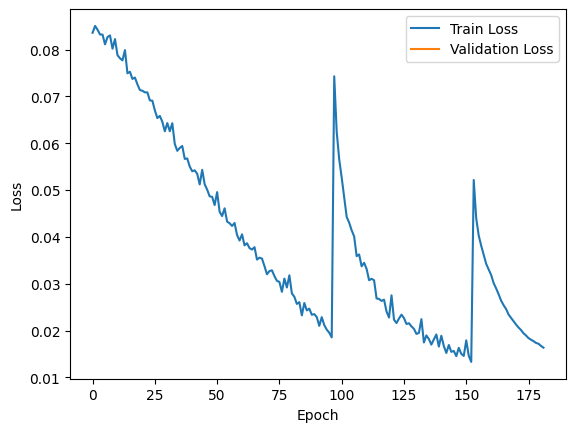

In [ ]:
import matplotlib.pyplot as plt
plt.plot(model.train_loss, label='Train Loss')
plt.plot(model.val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Analysing Things

In [ ]:
config

Config(data_files_path='data', data_folder_name='preprocessed_data', image_size=256, homography_shift=40.0, image_channels=3, brightness=0.5, contrast=0.5, encoder_out_channels=128, batch_size=16, lr=0.0001, epochs=100, device=None, save_path='registration_model.pth', save_window=5, metric_path='metrics.pkl', lr_scheduler_factor=0.5, lr_scheduler_patience=5, early_stopping_patience=10, early_stopping_min_delta=0.001)

In [ ]:
dataset_path = config.data_folder_name
df = pd.read_csv(os.path.join(dataset_path,"dataset.csv"))

In [ ]:
df

,reference_path,source_path,h
0,render1456_reference.png,render1456_source.png,"[[0.9562554955482483, -0.0066056386567652225, ..."
1,render6318_reference.png,render6318_source.png,"[[0.792305052280426, -0.03306099772453308, 10...."
2,render0695_reference.png,render0695_source.png,"[[0.876030445098877, -0.1937987357378006, 25.5..."
3,render3631_reference.png,render3631_source.png,"[[1.1995623111724854, -0.11078310012817383, -6..."
4,render1819_reference.png,render1819_source.png,"[[1.4736753702163696, 0.12332078069448471, -24..."
...,...,...,...
4995,render5897_reference.png,render5897_source.png,"[[1.0128408670425415, 0.041272178292274475, 8...."
4996,render4160_reference.png,render4160_source.png,"[[0.9038212895393372, 0.02859005518257618, -22..."
4997,render1166_reference.png,render1166_source.png,"[[1.0141462087631226, 0.06497574597597122, -1...."
4998,render3559_reference.png,render3559_source.png,"[[0.9347847104072571, -0.16117681562900543, 24..."


In [ ]:
dd=LunarData(config=config)

In [ ]:
df.iloc[0]['reference_path'],df.iloc[0]['source_path']

('render1456_reference.png', 'render1456_source.png')

In [ ]:
image_a,image_b=dd.get_item(f"{dataset_path}/"+df.iloc[0]['reference_path'],f"{dataset_path}/"+df.iloc[0]['source_path'])

In [ ]:
image_a.shape

torch.Size([3, 256, 256])

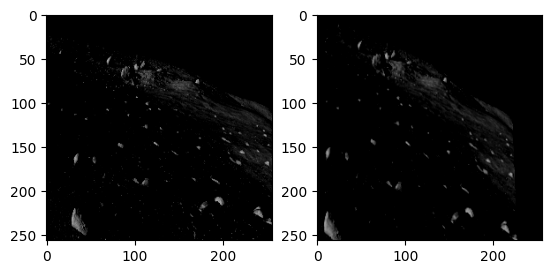

In [ ]:
import matplotlib.pyplot as plt


plt.subplot(1,2,1)
plt.imshow(image_a.squeeze(0).permute(1,2,0))
plt.subplot(1,2,2)
plt.imshow(image_b.squeeze(0).permute(1,2,0))

In [ ]:
result= model.predict(image_a.unsqueeze(0),image_b.unsqueeze(0))

In [ ]:
result

{'feature_ref': tensor([[[[-0.3740, -0.2272, -0.3229,  ..., -0.1491, -0.4299, -0.4860],
           [ 0.1379,  0.1088, -0.1057,  ..., -0.0825, -0.2881, -0.1943],
           [ 0.0063,  0.0941,  0.0685,  ..., -0.1534, -0.2823, -0.2627],
           ...,
           [-0.3326, -0.0930, -0.0322,  ..., -0.1579, -0.0600, -0.1617],
           [-0.3823, -0.0341, -0.1007,  ..., -0.2246, -0.3765, -0.4510],
           [-0.2741, -0.1500, -0.0650,  ..., -0.2196, -0.5229, -0.4932]],
 
          [[ 0.0472,  0.0610,  0.0958,  ...,  0.0353,  0.0768,  0.1023],
           [ 0.0594,  0.0760, -0.0398,  ...,  0.0181,  0.0513,  0.1674],
           [ 0.0177, -0.0111, -0.0725,  ...,  0.1536,  0.2132,  0.0438],
           ...,
           [-0.1134, -0.1021, -0.1546,  ..., -0.0466,  0.0598, -0.0174],
           [ 0.1035,  0.0005, -0.0427,  ...,  0.1467,  0.1118, -0.1171],
           [-0.0830,  0.0576,  0.0456,  ...,  0.1398,  0.2230, -0.0141]],
 
          [[-0.1605, -0.2215, -0.2712,  ..., -0.2665, -0.2861, -0.2635]

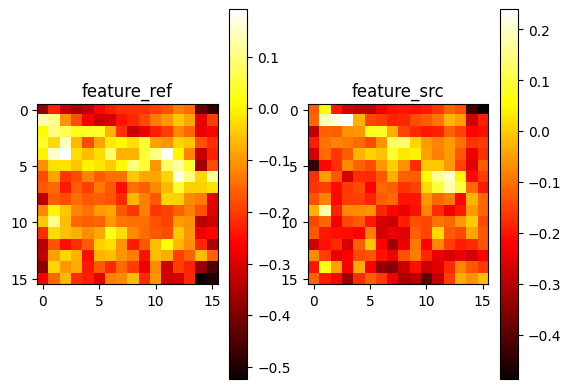

In [ ]:
plt.subplot(1,2,1)
plt.title("feature_ref")
plt.imshow(result['feature_ref'][0][0].cpu().detach().numpy(), cmap='hot')
plt.colorbar()
plt.subplot(1,2,2)
plt.title("feature_src")
plt.imshow(result['feature_src'][0][0].cpu().detach().numpy(), cmap='hot')
plt.colorbar()

In [ ]:
# # Correlation


# plt.imshow(result['correlation'][0].cpu().detach().numpy(), cmap='viridis')
# plt.colorbar()
# plt.title('Correlation Matrix')

In [ ]:
# img_ref_path = f"{dataset_path}/" + df.iloc[0]['reference_path']
# img_src_path = f"{dataset_path}/" + df.iloc[0]['source_path']

# img_ref = cv2.imread(img_ref_path, cv2.IMREAD_COLOR)
# img_src = cv2.imread(img_src_path, cv2.IMREAD_COLOR)

# if img_ref is None:
#     raise ValueError(f"Could not read reference image from: {img_ref_path}")
# if img_src is None:
#     raise ValueError(f"Could not read source image from: {img_src_path}")

# ref_pts=result['matches']['reference_points'][0].cpu().numpy()
# src_pts=result['matches']['source_points'][0].cpu().numpy()

# mask = result['matches']['mask'][0].cpu().numpy()

# ref_pts = ref_pts[mask]
# src_pts = src_pts[mask]


# kp_ref = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=5) for p in ref_pts]
# kp_src = [cv2.KeyPoint(x=float(p[0]), y=float(p[1]), size=5) for p in src_pts]


# matches = [cv2.DMatch(_queryIdx=i, _trainIdx=i, _distance=0) for i in range(len(ref_pts))]


# matched_img = cv2.drawMatches(
#     img_src, kp_src,
#     img_ref, kp_ref,
#     matches, None,
#     flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
# )


# plt.figure(figsize=(15, 7))
# plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
# plt.title("Feature Matches between Source and Reference")
# plt.axis('off')
# plt.show()

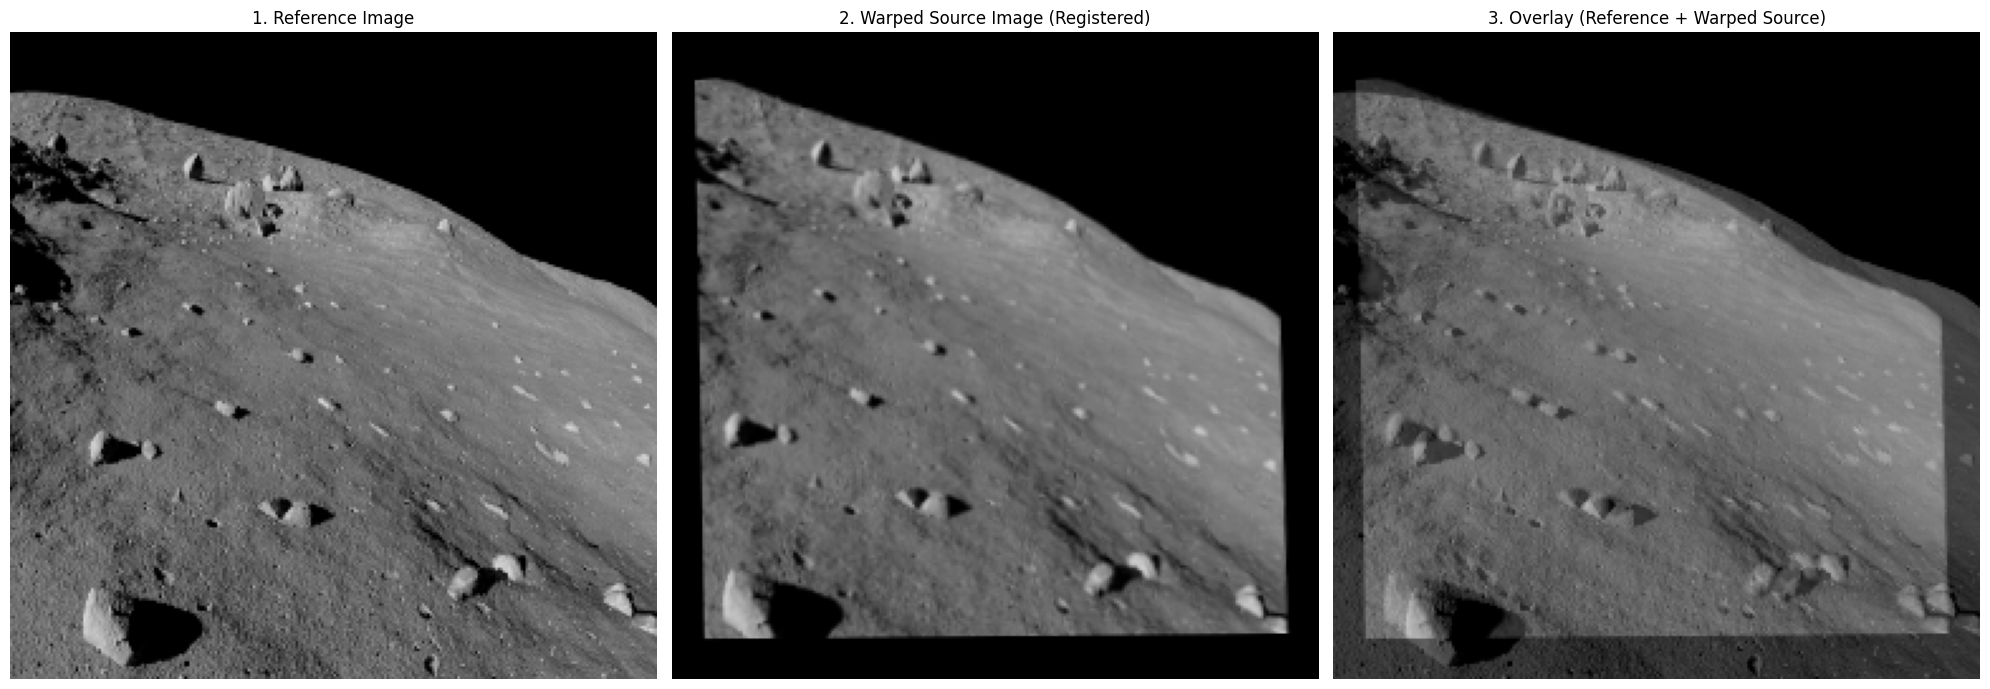

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img_ref_path = f"{dataset_path}/" + df.iloc[0]['reference_path']
img_src_path = f"{dataset_path}/" + df.iloc[0]['source_path']

img_ref = cv2.imread(img_ref_path, cv2.IMREAD_COLOR)
img_src = cv2.imread(img_src_path, cv2.IMREAD_COLOR)
H_matrix = result['H'][0].detach().cpu().numpy()

h, w = img_ref.shape[:2]

warped_src_img = cv2.warpPerspective(img_src, H_matrix, (w, h))

if len(img_ref.shape) == 2:
    overlay_img = cv2.addWeighted(img_ref, 0.5, warped_src_img, 0.5, 0)
else:
    overlay_img = cv2.addWeighted(img_ref, 0.5, warped_src_img, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

if len(img_ref.shape) == 2:
    axes[0].imshow(img_ref, cmap='gray')
    axes[1].imshow(warped_src_img, cmap='gray')
    axes[2].imshow(overlay_img, cmap='gray')
else:
    axes[0].imshow(cv2.cvtColor(img_ref, cv2.COLOR_BGR2RGB))
    axes[1].imshow(cv2.cvtColor(warped_src_img, cv2.COLOR_BGR2RGB))
    axes[2].imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))

axes[0].set_title('1. Reference Image')
axes[1].set_title('2. Warped Source Image (Registered)')
axes[2].set_title('3. Overlay (Reference + Warped Source)')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# ref_pts = result['matches']['reference_points'][0].detach().cpu().numpy()
# src_pts = result['matches']['source_points'][0].detach().cpu().numpy()
# margin = result['matches']['margin'][0].detach().cpu().numpy()


# valid_mask = margin > 0.05
# valid_ref = ref_pts[valid_mask]
# valid_src = src_pts[valid_mask]

# if len(valid_ref) >= 4:
#     H_cv2, inliers = cv2.findHomography(valid_src, valid_ref, cv2.RANSAC, 5.0)

#     if H_cv2 is not None:
#         h, w = img_ref.shape[:2]

#         if img_src.dtype != np.uint8:
#             img_src = (img_src * 255).astype(np.uint8)
#         if img_ref.dtype != np.uint8:
#             img_ref = (img_ref * 255).astype(np.uint8)

#         warped_src_img = cv2.warpPerspective(img_src, H_cv2, (w, h))

#         overlay_img = cv2.addWeighted(img_ref, 0.5, warped_src_img, 0.5, 0)

#         fig, axes = plt.subplots(1, 3, figsize=(20, 7))

#         axes[0].imshow(img_ref, cmap='gray')
#         axes[0].set_title('1. Reference Image')
#         axes[0].axis('off')

#         axes[1].imshow(warped_src_img, cmap='gray')
#         axes[1].set_title('2. Warped Image (Fixed via RANSAC)')
#         axes[1].axis('off')

#         axes[2].imshow(overlay_img, cmap='gray')
#         axes[2].set_title('3. Overlay (Check Alignment)')
#         axes[2].axis('off')

#         plt.show()
#     else:
#         print("RANSAC H matrix nahi nikal paya. Features bahut kharab hain.")
# else:
#     print(f"Homography ke liye kam se kam 4 points chahiye, but sirf {len(valid_ref)} mile.")

In [ ]:
!pip install mlflow dagshub
import os
import mlflow
import mlflow.pytorch # Import mlflow.pytorch for logging PyTorch models
import dagshub # Keep import for other potential dagshub functionalities, but dagshub.init removed
import matplotlib.pyplot as plt
import torch
import pickle # To load metrics if needed, though 'model' object has them


# Set DagsHub credentials and MLflow tracking URI
# IMPORTANT: This token should be deleted or stored securely in a real application.
os.environ['MLFLOW_TRACKING_URI'] = "https://dagshub.com/vanshsharma7832/sih_isro.mlflow"
os.environ['MLFLOW_TRACKING_USERNAME'] = "vanshsharma7832" # Your DagsHub username
os.environ['MLFLOW_TRACKING_PASSWORD'] = "fee29b0c9f88f7918ad1474919b54153acd45f5e" # Your DagsHub token

# Set the MLflow tracking URI. MLflow will use the environment variables for authentication.
mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])

# Assuming 'model' and 'config' objects are available from previous cells
# (which they are, based on the kernel state)

with mlflow.start_run():
    print("Starting MLflow run...")

    # Log model parameters from the config object
    # Filter out private attributes and methods
    config_params = {key: getattr(config, key) for key in dir(config) if not key.startswith('__') and not callable(getattr(config, key))}
    mlflow.log_params(config_params)
    print("Logged configuration parameters.")

    # Prepare an input example for model tracing
    if 'train_loader' in locals() and train_loader is not None:
        # Get one batch from the train_loader for input_example
        example_reference, example_source, _ = next(iter(train_loader))
        input_example = (example_reference.to(model.device), example_source.to(model.device))
        print("Prepared input example from train_loader.")
    else:
        input_example = None
        print("Warning: train_loader not found, cannot provide input_example for model tracing.")

    # Log the trained PyTorch model to MLflow Model Registry
    if hasattr(model, 'network') and isinstance(model.network, torch.nn.Module):
        mlflow.pytorch.log_model(
            pytorch_model=model.network,
            artifact_path="model", # This is the artifact path within the run
            registered_model_name="RegistrationNetwork", # This registers the model with this name
            input_example=input_example, # Provide the input example for tracing
            serialization_format="pickle" # Use 'pickle' to avoid TensorSpec requirement with default 'pt2'
        )
        print("Logged PyTorch model to MLflow Model Registry as 'RegistrationNetwork'.")
    else:
        print("PyTorch model object (model.network) not found or not a torch.nn.Module. Skipping model registration."
        )

    # Log the loss curves
    train_losses = model.train_loss
    val_losses = model.val_loss

    if train_losses and val_losses:
        # Log individual loss values per epoch as metrics
        for i, (t_loss, v_loss) in enumerate(zip(train_losses, val_losses)):
            mlflow.log_metric("train_loss", t_loss, step=i)
            mlflow.log_metric("val_loss", v_loss, step=i)
        print("Logged train and validation loss metrics.")

        # Plot and save the loss curve image
        plt.figure(figsize=(10, 6))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss Curve')
        plt.legend()
        plt.grid(True)
        loss_plot_path = "loss_curve.png"
        plt.savefig(loss_plot_path)
        plt.close() # Close the plot to prevent it from displaying unnecessarily

        mlflow.log_artifact(loss_plot_path, artifact_path="plots")
        mlflow.log_artifact("metrics.pkl",artifact_path="metrics")
        print(f"Logged loss curve plot: {loss_plot_path}")
        os.remove(loss_plot_path) # Clean up the saved plot file
    else:
        print("Loss data not available. Skipping loss curve logging.")

print("MLflow logging complete. Check your DagsHub project for results.")

Starting MLflow run...


2026/09/01 17:44:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged configuration parameters.
Prepared input example from train_loader.


2026/09/01 17:44:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/09/01 17:44:44 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/09/01 17:44:57 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the loca

Logged PyTorch model to MLflow Model Registry as 'RegistrationNetwork'.
Loss data not available. Skipping loss curve logging.
🏃 View run useful-dolphin-278 at: https://dagshub.com/vanshsharma7832/sih_isro.mlflow/#/experiments/0/runs/b0abe6fc268d46b48bf034fbccd26af0
🧪 View experiment at: https://dagshub.com/vanshsharma7832/sih_isro.mlflow/#/experiments/0
MLflow logging complete. Check your DagsHub project for results.
